<a href="https://colab.research.google.com/github/devaki-turimella/PRODIGY_GI_05/blob/main/Neural_style_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

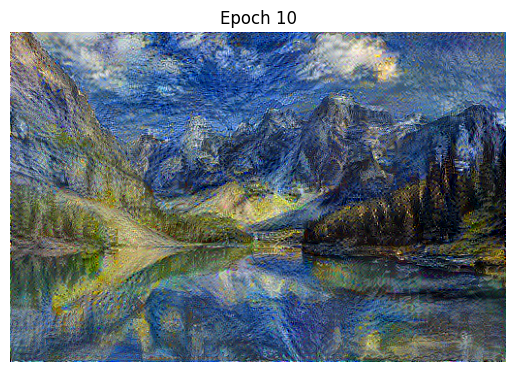

Total time: 66.8 seconds


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Your stylized image has been saved and downloaded.


In [6]:

# STEP 1: Install/import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import IPython.display as display

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


# STEP 2: Upload content image (the photo) and style image (the painting)
print("Upload your CONTENT image (the photo you want to keep the shape/objects of):")
content_upload = files.upload()
content_path = list(content_upload.keys())[0]

print("Upload your STYLE image (the painting whose art style you want to copy):")
style_upload = files.upload()
style_path = list(style_upload.keys())[0]


# STEP 3: Helper functions to load and process images
def load_img(path_to_img, max_dim=512):
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim
    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]  # add batch dimension
    return img

def imshow(image, title=None):
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')

content_image = load_img(content_path)
style_image = load_img(style_path)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')
plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')
plt.show()


# STEP 4: Load pretrained VGG19 (used only as a feature extractor, not trained further)
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

# These layers give us "style" info (textures/patterns) at different depths
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

# This layer gives us "content" info (shapes/objects)
content_layers = ['block5_conv2']

num_style_layers = len(style_layers)
num_content_layers = len(content_layers)


def vgg_layers(layer_names):
    """Creates a model that returns the outputs of the requested VGG layers."""
    outputs = [vgg.get_layer(name).output for name in layer_names]
    model = tf.keras.Model([vgg.input], outputs)
    return model


# STEP 5: Function to compute the "Gram matrix" — this captures the STYLE
# (it measures how features correlate with each other, ignoring where they are in the image)
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1] * input_shape[2], tf.float32)
    return result / num_locations


# STEP 6: Model that extracts style and content features together
class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super().__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        inputs = inputs * 255.0
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)
        outputs = self.vgg(preprocessed_input)

        style_outputs = outputs[:self.num_style_layers]
        content_outputs = outputs[self.num_style_layers:]

        style_outputs = [gram_matrix(style_output) for style_output in style_outputs]

        content_dict = {name: value for name, value in zip(self.content_layers, content_outputs)}
        style_dict = {name: value for name, value in zip(self.style_layers, style_outputs)}

        return {'content': content_dict, 'style': style_dict}


extractor = StyleContentModel(style_layers, content_layers)

style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']


# STEP 7: The image we will actually optimize — start it as a copy of the content image
generated_image = tf.Variable(content_image)

def clip_0_1(image):
    return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

# Weights control how much style vs content matters. Tweak these to change the result.
style_weight = 1e-2
content_weight = 1e4


def style_content_loss(outputs):
    style_outputs = outputs['style']
    content_outputs = outputs['content']

    style_loss = tf.add_n([
        tf.reduce_mean((style_outputs[name] - style_targets[name]) ** 2)
        for name in style_outputs.keys()
    ])
    style_loss *= style_weight / num_style_layers

    content_loss = tf.add_n([
        tf.reduce_mean((content_outputs[name] - content_targets[name]) ** 2)
        for name in content_outputs.keys()
    ])
    content_loss *= content_weight / num_content_layers

    return style_loss + content_loss


# STEP 8: One training step — this is where the "learning" happens
@tf.function()
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        loss = style_content_loss(outputs)

    grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(clip_0_1(image))


# STEP 9: Run the optimization loop
epochs = 10
steps_per_epoch = 100

import time
start = time.time()

for n in range(epochs):
    for m in range(steps_per_epoch):
        train_step(generated_image)
    print(f"Epoch {n+1}/{epochs} complete")
    display.clear_output(wait=True)
    imshow(generated_image.read_value())
    plt.title(f"Epoch {n+1}")
    plt.show()

end = time.time()
print(f"Total time: {end - start:.1f} seconds")


# STEP 10: Save the final stylized image
final_image = tf.squeeze(generated_image.read_value(), axis=0)
final_image = (final_image.numpy() * 255).astype(np.uint8)
result = Image.fromarray(final_image)
result.save("stylized_output.jpg")

files.download("stylized_output.jpg")
print("Done! Your stylized image has been saved and downloaded.")